In [159]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, accuracy_score
import time

<h2> Section A </h2>

In [160]:
### Impurity Measures

def calculate_gini(y):
    """
    Calculates the Gini Impurity for a classification node.
    Formula: 1 - sum(p_k^2)
    """
    # Edge case: If the node is empty, impurity is 0
    if len(y) == 0:
        return 0.0

    # Get the count of each unique class in the array
    _, counts = np.unique(y, return_counts=True)

    # Calculate probabilities (p_k)
    probabilities = counts / len(y)

    # Calculate and return Gini
    gini = 1.0 - np.sum(probabilities ** 2)
    return gini


def calculate_ssr(y):
    """
    Calculates the Sum of Squared Residuals (SSR) for a regression node.
    Formula: sum((y_i - mean(y))^2)
    """
    # Edge case: If the node is empty, SSR is 0
    if len(y) == 0:
        return 0.0

    # Calculate the mean of the targets in this node
    mean_y = np.mean(y)

    # Calculate SSR using vectorized operations
    ssr = np.sum((y - mean_y) ** 2)
    return ssr

# Quick Sanity Check
# test_gini = calculate_gini(np.array(['Good', 'Good', 'Bad', 'Excellent']))
# test_ssr = calculate_ssr(np.array([10000, 12000, 15000]))
#
# print(f"Test Gini (should be > 0): {test_gini:.4f}")
# print(f"Test SSR (should be > 0): {test_ssr:.4f}")


In [161]:
### Decision Tree Class

class Node:
    """A helper class representing a single node in the tree."""
    def __init__(self, feature_idx=None, feature_name=None, threshold=None, left=None, right=None, value=None):
        self.feature_idx = feature_idx
        self.feature_name = feature_name
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value


    def is_leaf(self):
        return self.value is not None

class DecisionTree:
    def __init__(self, task_type, max_depth=10, min_samples_leaf=5, n_features=None):
        self.task_type = task_type
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.n_features = n_features
        self.root = None

    def _calculate_leaf_value(self, y_subset):
        """Calculates the prediction value for a leaf node."""
        if len(y_subset) == 0:
            return None
        if self.task_type == 'clf':
            # Classification: Majority vote
            counts = np.bincount(y_subset)
            return counts.argmax()
        else:
            # Regression: Mean
            return np.mean(y_subset)

    def fit(self, X, y):
        # Convert to numpy ONCE to prevent overhead
        self.feature_names = X.columns.tolist() if isinstance(X, pd.DataFrame) else [f"f{i}" for i in range(X.shape[1])]
        self.X_np = X.values if isinstance(X, pd.DataFrame) else X
        self.y_np = y.values if isinstance(y, (pd.Series, pd.DataFrame)) else y

        if self.task_type == 'clf':
            self.classes_, self.y_np = np.unique(self.y_np, return_inverse=True)
            self.num_classes = len(self.classes_)

        initial_indices = np.arange(len(self.y_np))
        self.root = self._build_tree(initial_indices, depth=0)

    def _build_tree(self, indices, depth):
        num_samples = len(indices)
        y_subset = self.y_np[indices]

        # Stopping Criteria
        if (self.max_depth is not None and depth >= self.max_depth) or \
           num_samples < self.min_samples_leaf * 2 or \
           np.all(y_subset == y_subset[0]):
            return Node(value=self._calculate_leaf_value(y_subset))

        # Find best split using indices
        best_feat_idx, best_feat_name, best_thresh, left_indices, right_indices = self._find_best_split(indices)

        # If no valid split found
        if best_feat_idx is None:
            return Node(value=self._calculate_leaf_value(y_subset))

        # Recursively grow children passing ONLY indices
        left_child = self._build_tree(left_indices, depth + 1)
        right_child = self._build_tree(right_indices, depth + 1)

        return Node(feature_idx=best_feat_idx, feature_name=best_feat_name,
                    threshold=best_thresh, left=left_child, right=right_child)

    def _find_best_split(self, indices):
        best_feat_idx, best_feat_name, best_threshold = None, None, None
        best_score = float('inf')
        best_left_idx, best_right_idx = None, None

        n_total = len(indices)
        X_subset = self.X_np[indices]
        y_subset = self.y_np[indices]
        n_features = self.X_np.shape[1]

        # Handle features for potential Random Forest use + Tie-Breaker Constraint
        if self.n_features is not None and self.n_features < n_features:
            feat_indices = np.random.choice(n_features, self.n_features, replace=False)
            feat_indices = sorted(feat_indices, key=lambda i: self.feature_names[i])
        else:
            feat_indices = sorted(range(n_features), key=lambda i: self.feature_names[i])

        for f_idx in feat_indices:
            f_name = self.feature_names[f_idx]
            col_values = X_subset[:, f_idx]

            # Sort values
            sort_order = np.argsort(col_values)
            Xs = col_values[sort_order]
            ys = y_subset[sort_order]
            sorted_original_indices = indices[sort_order]

            if self.task_type == 'reg':
                # --- Vectorized Regression (SSR) ---
                csum = np.cumsum(ys)
                csum2 = np.cumsum(ys ** 2)

                total_sum = csum[-1]
                total_sum_sq = csum2[-1]

                n_l = np.arange(1, n_total)
                n_r = n_total - n_l

                sum_left = csum[:-1]
                sum_sq_left = csum2[:-1]

                ssr_left = sum_sq_left - (sum_left**2 / n_l)
                ssr_right = (total_sum_sq - sum_sq_left) - ((total_sum - sum_left)**2 / n_r)
                scores = ssr_left + ssr_right

                valid_mask = (n_l >= self.min_samples_leaf) & (n_r >= self.min_samples_leaf) & (Xs[:-1] != Xs[1:])

                if np.any(valid_mask):
                    valid_scores = np.where(valid_mask, scores, np.inf)
                    best_split_idx = np.argmin(valid_scores)
                    min_score_in_feature = valid_scores[best_split_idx]

                    # Exclusive less-than ensures alphabetical Tie-Breaker (Constraint 1)
                    if min_score_in_feature < best_score:
                        best_score = min_score_in_feature
                        best_feat_idx = f_idx
                        best_feat_name = f_name
                        best_threshold = Xs[best_split_idx]
                        best_left_idx = sorted_original_indices[:best_split_idx + 1]
                        best_right_idx = sorted_original_indices[best_split_idx + 1:]

            else:
                # --- Vectorized Classification (Gini) ---
                # Local One-Hot Encoding for class counts
                y_ohe = np.zeros((n_total, self.num_classes))
                y_ohe[np.arange(n_total), ys] = 1

                csum = np.cumsum(y_ohe, axis=0)
                left_counts = csum[:-1]
                right_counts = csum[-1] - left_counts

                n_l = np.arange(1, n_total)[:, np.newaxis]
                n_r = (n_total - np.arange(1, n_total))[:, np.newaxis]

                gini_l = 1.0 - np.sum((left_counts / n_l) ** 2, axis=1)
                gini_r = 1.0 - np.sum((right_counts / n_r) ** 2, axis=1)

                n_l_flat = np.arange(1, n_total)
                n_r_flat = n_total - n_l_flat
                scores = (n_l_flat / n_total) * gini_l + (n_r_flat / n_total) * gini_r

                valid_mask = (n_l_flat >= self.min_samples_leaf) & (n_r_flat >= self.min_samples_leaf) & (Xs[:-1] != Xs[1:])

                if np.any(valid_mask):
                    valid_scores = np.where(valid_mask, scores, np.inf)
                    best_split_idx = np.argmin(valid_scores)
                    min_score_in_feature = valid_scores[best_split_idx]

                    if min_score_in_feature < best_score:
                        best_score = min_score_in_feature
                        best_feat_idx = f_idx
                        best_feat_name = f_name
                        best_threshold = Xs[best_split_idx]
                        best_left_idx = sorted_original_indices[:best_split_idx + 1]
                        best_right_idx = sorted_original_indices[best_split_idx + 1:]

        return best_feat_idx, best_feat_name, best_threshold, best_left_idx, best_right_idx

    def predict(self, X):
        """Vectorized prediction"""
        X_np = X.values if isinstance(X, pd.DataFrame) else X
        predictions = np.array([self._traverse_tree(x, self.root) for x in X_np])
        if self.task_type == 'clf' and self.num_classes is not None:
             return self.classes_[predictions.astype(int)]
        return predictions

    def _traverse_tree(self, x, node):
        """
        Helper to walk down the tree for a single sample.
        Uses a while loop instead of recursion for better performance.
        """
        # Continue traversing until a leaf node is reached
        while not node.is_leaf():
            # Use 'feature_idx', NOT 'feature'
            if x[node.feature_idx] <= node.threshold:
                node = node.left
            else:
                node = node.right

        # Once at a leaf, return its value
        return node.value

In [162]:
### Random Forest

class RandomForest:
    def __init__(self, task_type, n_estimators=10, max_depth=10, min_samples_leaf=5, n_features=None):
        self.task_type = task_type  # 'clf' for classification, 'reg' for regression
        self.n_estimators = n_estimators  # Number of trees
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.n_features = n_features  # Features to consider at each split
        self.trees = []

    def _bootstrap_sample(self, X, y):
        """
        Creates a random sample with replacement (Bagging).
        Each tree gets a dataset of the same size as the original but with randomized rows.
        """
        n_samples = X.shape[0]
        # Generate random indices with replacement
        indices = np.random.choice(n_samples, n_samples, replace=True)
        return X.iloc[indices], y.iloc[indices]

    def fit(self, X, y):
        """Builds the forest by training multiple decision trees."""
        self.trees = []
        for _ in range(self.n_estimators):
            # Get a bootstrap sample
            X_sample, y_sample = self._bootstrap_sample(X, y)

            # Initialize a tree with feature randomness (n_features)
            tree = DecisionTree(
                task_type=self.task_type,
                max_depth=self.max_depth,
                min_samples_leaf=self.min_samples_leaf,
                n_features=self.n_features
            )

            # Fit the individual tree
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

    def predict(self, X):
        """
        Aggregates predictions from all trees.
        Classification uses Majority Vote. Regression uses Average.
        """
        # Collect predictions from all trees
        tree_preds = [tree.predict(X) for tree in self.trees]

        # Convert to numpy array (Rows: Trees, Columns: Samples)
        preds_matrix = np.array(tree_preds)

        if self.task_type == 'clf':
            # Majority Vote using pure Numpy
            def get_majority_vote(column):
                values, counts = np.unique(column, return_counts=True)
                return values[np.argmax(counts)]

            # Apply the vote function for each sample (along axis 0)
            return np.apply_along_axis(get_majority_vote, axis=0, arr=preds_matrix)

        else:
            # Regression: Simple average of all tree results
            return np.mean(preds_matrix, axis=0)

<h2> Section B </h2>

In [163]:
### Loading the data

# Load the dataset
df = pd.read_csv('vehicle_price_prediction.csv')

# Keep only the first 100,000 samples (based on the instructions in the Moodle)
df = df.iloc[:100000].copy()

# Quick overview of the data
print(df.info())
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   make              100000 non-null  str    
 1   model             100000 non-null  str    
 2   year              100000 non-null  int64  
 3   mileage           100000 non-null  int64  
 4   engine_hp         100000 non-null  int64  
 5   transmission      100000 non-null  str    
 6   fuel_type         100000 non-null  str    
 7   drivetrain        100000 non-null  str    
 8   body_type         100000 non-null  str    
 9   exterior_color    100000 non-null  str    
 10  interior_color    100000 non-null  str    
 11  owner_count       100000 non-null  int64  
 12  accident_history  25054 non-null   str    
 13  seller_type       100000 non-null  str    
 14  condition         100000 non-null  str    
 15  trim              100000 non-null  str    
 16  vehicle_age       100000 non-nul

C:\Users\h7102\AppData\Local\Temp\ipykernel_34268\817831005.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=temp_accident, order=temp_accident.value_counts().index, palette='viridis')


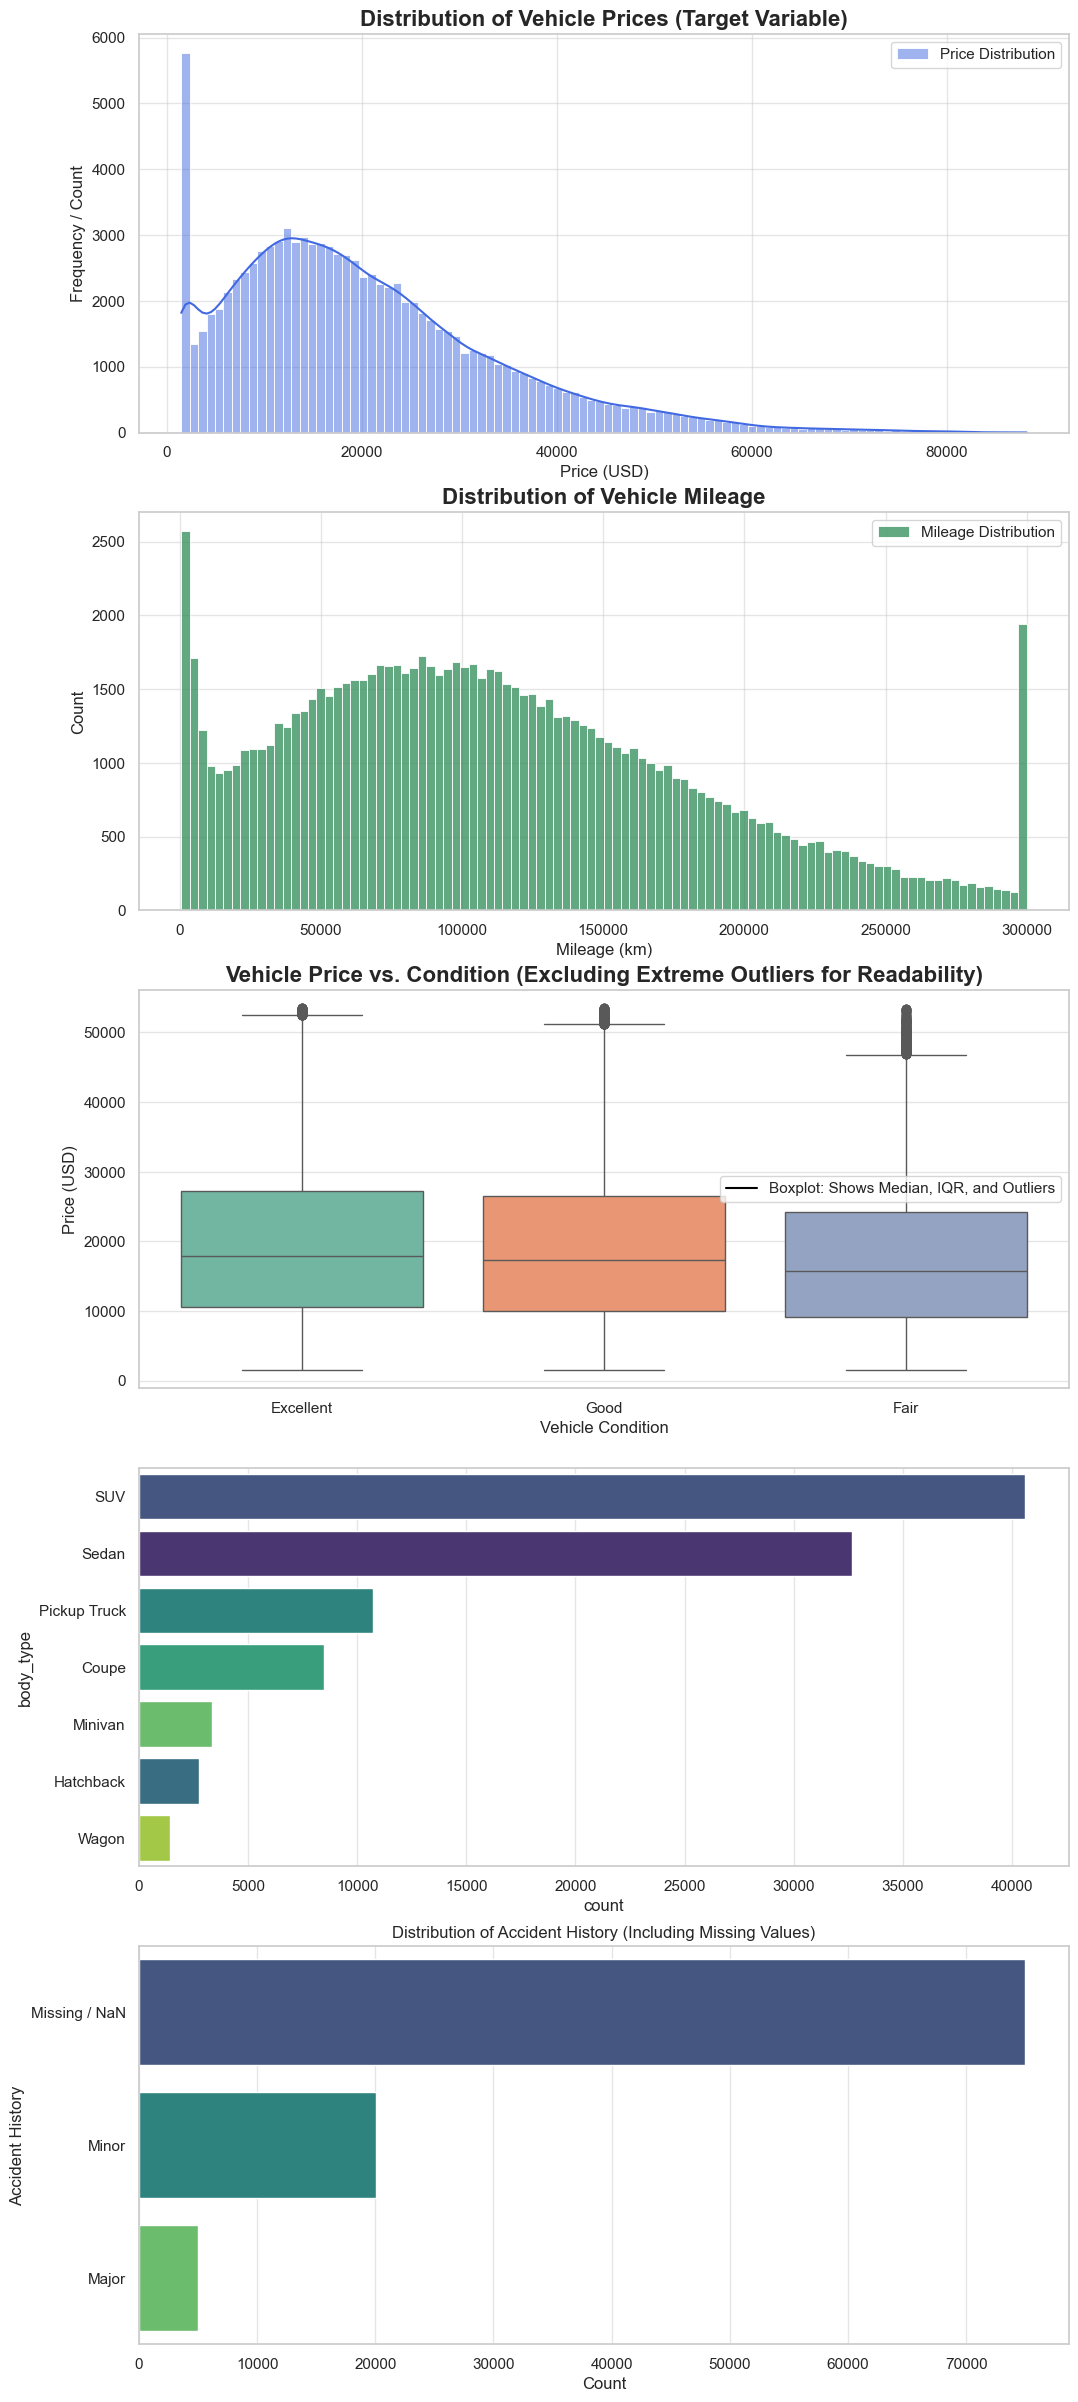

<Figure size 640x480 with 0 Axes>

In [164]:
### Data Visualization (EDA)

# Set a clean visual style for all plots
sns.set_theme(style="whitegrid")

# Create a figure with 3 subplots for better organization
fig, axes = plt.subplots(5, 1, figsize=(12, 30))

# ==========================================
# Plot 1: Distribution of Vehicle Prices
# ==========================================
sns.histplot(df['price'], bins=100, kde=True, color='royalblue', label='Price Distribution', ax=axes[0])
axes[0].set_title('Distribution of Vehicle Prices (Target Variable)', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Price (USD)', fontsize=12)
axes[0].set_ylabel('Frequency / Count', fontsize=12)
axes[0].legend()

# ==========================================
# Plot 2: Distribution of Mileage
# ==========================================
sns.histplot(df['mileage'], bins=100, kde=False, color='seagreen', label='Mileage Distribution', ax=axes[1])
axes[1].set_title('Distribution of Vehicle Mileage', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Mileage (km)', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].legend()

# ==========================================
# Plot 3: Vehicle Price Distribution by Condition
# ==========================================
# Filtering out extreme price outliers just for the boxplot visualization to make it readable
Q1_viz = df['price'].quantile(0.25)
Q3_viz = df['price'].quantile(0.75)
IQR_viz = Q3_viz - Q1_viz
upper_bound_viz = Q3_viz + 1.5 * IQR_viz

viz_df = df[df['price'] <= upper_bound_viz]

sns.boxplot(x='condition', y='price', hue='condition',data=viz_df,ax=axes[2],    palette="Set2",legend=False)

axes[2].set_title('Vehicle Price vs. Condition (Excluding Extreme Outliers for Readability)', fontsize=16, fontweight='bold')
axes[2].set_xlabel('Vehicle Condition', fontsize=12)
axes[2].set_ylabel('Price (USD)', fontsize=12)
axes[2].plot([], [], color='black', label='Boxplot: Shows Median, IQR, and Outliers')
axes[2].legend()

# ==========================================
# Plot 4: Distribution of Body Types (Categorical)
# ==========================================
# Using countplot for categorical data, ordered by frequency
sns.countplot(
    y='body_type',
    data=df,
    order=df['body_type'].value_counts().index,
    ax=axes[3],
    palette="viridis",
    hue='body_type',
    legend=False
)

# ==========================================
# Plot 5: Distribution of Missing values
# ==========================================
temp_accident = df['accident_history'].fillna('Missing / NaN')
sns.countplot(y=temp_accident, order=temp_accident.value_counts().index, palette='viridis')
plt.title('Distribution of Accident History (Including Missing Values)')
plt.xlabel('Count')
plt.ylabel('Accident History')
plt.show()
# Explanation: We can see 'Missing' is a massive category.
# Imputing with the Mode would severely skew the data.


axes[3].set_title('Frequency of Vehicle Body Types', fontsize=16, fontweight='bold')
axes[3].set_xlabel('Count', fontsize=12)
axes[3].set_ylabel('Body Type', fontsize=12)
# Adding a dummy plot for the legend to fulfill the assignment requirement [cite: 26]
axes[3].plot([], [], color='black', label='Bar Chart: Categorical Count')
axes[3].legend()

plt.tight_layout()
plt.show()

In [165]:
### Handling Missing Values

# Identify columns with missing values
missing_info = df.isnull().sum()
print("Missing values per column:\n", missing_info[missing_info > 0])

df_clean = df.copy()

# Impute Numerical Features - Using Median Imputation.
# Reasoning: Median is robust to outliers, which is crucial here since the dataset might contain artifacts and extreme values.
# Unlike the Mean, the Median is not skewed by these outliers.
numerical_cols = df_clean.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Impute Categorical Features - Using Mode Imputation
# Reasoning: For discrete categorical data, the Mode is the most representative value that preserves the most common characteristic of the distribution.
categorical_cols = df_clean.select_dtypes(include=['object', 'str']).columns
for col in categorical_cols:
    if df_clean[col].isnull().sum() > 0:
        if col == 'accident_history':
            df_clean[col] = df_clean[col].fillna('None') # Arbitrary Value Imputation
        else:
            df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0]) # Mode Imputation

# Verification
print(f"Total missing values after imputation: {df.isnull().sum().sum()}")




Missing values per column:
 accident_history    74946
dtype: int64
Total missing values after imputation: 74946


In [166]:
### Outlier and Artifact Analysis

# Statistical Outlier Detection (using the IQR method)
def get_iqr_bounds(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    # Standard threshold: 1.5 * IQR
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

price_lower, price_upper = get_iqr_bounds(df['price'])
mileage_lower, mileage_upper = get_iqr_bounds(df['mileage'])

print("--- Statistical Bounds ---")
print(f"Price typical range (1.5 IQR): {price_lower:.2f} to {price_upper:.2f}")
print(f"Mileage typical range (1.5 IQR): {mileage_lower:.2f} to {mileage_upper:.2f}")

# Artifact Analysis (Floor Effect and Clumps)
floor_effect_mask = df['price'] == 1500
floor_count = floor_effect_mask.sum()

clump_mask = df['mileage'] == 300000
clump_count = clump_mask.sum()

print("\n--- Artifact Analysis ---")
print(f"Price == $1,500: {floor_count} rows ({(floor_count/len(df))*100:.2f}%)")
print(f"Mileage == 300,000 km: {clump_count} rows ({(clump_count/len(df))*100:.2f}%)")

# Data Filtering Decision
original_size = len(df)

# Filtering logic:
# - Remove the exact artifacts ($1500 and 300,000) as they distort the model's ability to learn real patterns.
# - Remove extreme upper outliers using the 1.5 IQR bound.
# - Lower bound for price is often negative mathematically, so we just check it's > 1500.
df_cleaned = df[
    (df['price'] > 1500) &
    (df['price'] <= price_upper) &
    (df['mileage'] < 300000) &
    (df['mileage'] <= mileage_upper)
].copy()

cleaned_size = len(df_cleaned)
print("\n--- Filtering Results ---")
print(f"Original dataset size: {original_size}")
print(f"Cleaned dataset size: {cleaned_size}")
print(f"Removed {original_size - cleaned_size} rows ({(1 - cleaned_size/original_size)*100:.2f}% of data)")

--- Statistical Bounds ---
Price typical range (1.5 IQR): -15605.22 to 53487.24
Mileage typical range (1.5 IQR): -92575.38 to 308113.62

--- Artifact Analysis ---
Price == $1,500: 4637 rows (4.64%)
Mileage == 300,000 km: 1807 rows (1.81%)

--- Filtering Results ---
Original dataset size: 100000
Cleaned dataset size: 92132
Removed 7868 rows (7.87% of data)


<h4> Justification </h4>
For outlier detection, I chose a threshold of 1.5 * IQR. I selected this specific threshold because it’s the standard statistical 'sweet spot' – it effectively removes extreme anomalies without losing the natural variance of the data. (I ignored the calculated negative lower bounds, as price and mileage cannot be below zero).

During the manual inspection, I also removed data artifacts, such as cars priced at exactly $1,500 (a floor effect) and cars with exactly 300,000 km (a probable system max limit), as these distort the model.

All in all, removing these entries significantly changed the data distribution. It successfully eliminated the artificial spikes (clumps) and smoothed out the extreme long tails, leaving a clean, realistic dataset of 92,132 samples ready for training.

In [167]:
### Categorical Encoding - Using One Hot Encoding

df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)



In [168]:
### Splitting the data
# Train: 0 to 70,000 (inclusive) -> 70,001 rows
train_df = df_encoded.iloc[0:70001].copy()

# Validation: 70,001 to 85,000 (inclusive) -> 15,000 rows
val_df = df_encoded.iloc[70001:85001].copy()

# Test: 85,001 to end
test_df = df_encoded.iloc[85001:].copy()

# Separate Features (X) and Targets (y)
target_reg = 'price'
target_clf = 'condition'
feature_cols = [col for col in df_encoded.columns if col not in [target_reg, target_clf]]

X_train = train_df[feature_cols]
y_train_reg = train_df[target_reg]
y_train_clf = train_df[target_clf]

X_val = val_df[feature_cols]
y_val_reg = val_df[target_reg]
y_val_clf = val_df[target_clf]

print(f"Train Shape: {X_train.shape}, Validation Shape: {X_val.shape}")

KeyError: 'condition'

<h2> Section C</h2>

In [ ]:
### Setup & Initialization

# Define the range of depths to evaluate (1 through 20 inclusive)
depths = range(1, 21)

# Initialize empty lists
train_mse_list = []
val_mse_list = []

train_acc_list = []
val_acc_list = []

In [ ]:
### Train and Prediction Loop + Metrics Calculations (Using Sklearn)

# Start the total timer
total_start_time = time.time()

for depth in depths:
    # Start the timer for the current depth
    depth_start_time = time.time()

    # --- Train and Prediction Loop ---

    # Regression (Predicting 'price')
    tree_reg = DecisionTree(task_type='reg', max_depth=depth)
    tree_reg.fit(X_train, y_train_reg)

    y_train_pred_reg = tree_reg.predict(X_train)
    y_val_pred_reg = tree_reg.predict(X_val)

    # Classification (Predicting 'condition')
    tree_clf = DecisionTree(task_type='clf', max_depth=depth)
    tree_clf.fit(X_train, y_train_clf)

    y_train_pred_clf = tree_clf.predict(X_train)
    y_val_pred_clf = tree_clf.predict(X_val)

    # --- Metrics Calculation ---

    # Calculate MSE for regression using sklearn
    train_mse = mean_squared_error(y_train_reg, y_train_pred_reg)
    val_mse = mean_squared_error(y_val_reg, y_val_pred_reg)

    # Calculate Accuracy for classification using sklearn
    train_acc = accuracy_score(y_train_clf, y_train_pred_clf)
    val_acc = accuracy_score(y_val_clf, y_val_pred_clf)

    # Append the results to our lists
    train_mse_list.append(train_mse)
    val_mse_list.append(val_mse)
    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)

    # Calculate how long this specific depth took
    depth_end_time = time.time()
    elapsed_time = depth_end_time - depth_start_time

    print(f"Depth {depth:2d} completed in {elapsed_time:.1f} seconds.")
    print(f"   Reg MSE: Train={train_mse:8.2f}, Val={val_mse:8.2f}")
    print(f"   Clf Acc: Train={train_acc:.4f}, Val={val_acc:.4f}\n")

total_end_time = time.time()
print(f"Finished evaluating all depths! Total time: {(total_end_time - total_start_time) / 60:.2f} minutes.")

In [ ]:
# Complexity Curve Generation (Regression Example)
train_mse_list = []
val_mse_list = []
depths = list(range(1, 21))

print("Generating Complexity Curve. This may take a few minutes...")

for d in depths:
    # Initialize and fit optimized tree
    dt_reg = DecisionTree(task_type='reg', max_depth=d, min_samples_leaf=5)
    dt_reg.fit(X_train, y_train_reg)

    # Predict and calculate MSE
    y_train_pred = dt_reg.predict(X_train)
    y_val_pred = dt_reg.predict(X_val)

    train_mse = mean_squared_error(y_train_reg, y_train_pred)
    val_mse = mean_squared_error(y_val_reg, y_val_pred)

    train_mse_list.append(train_mse)
    val_mse_list.append(val_mse)

    print(f"Depth {d} Completed: Train MSE = {train_mse:.2f}, Val MSE = {val_mse:.2f}")

# Plotting the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(depths, train_mse_list, marker='o', label='Train MSE', color='blue')
plt.plot(depths, val_mse_list, marker='s', label='Validation MSE', color='orange')
plt.title('Complexity Curve: Tree Depth vs. Mean Squared Error')
plt.xlabel('Max Depth')
plt.ylabel('MSE')
plt.xticks(depths)
plt.legend()
plt.grid(True)
plt.show()